# Two-Island Model

Formålet med denne notebook er at bygge en two-island model og bruge den til inferens. Modellen beskriver to populationer, hvor linjer kan migrere mellem øerne, men der er ingen fælles forfader-population (migration alene opretholder forbindelsen), der er en konstant rate. Dette er den simpleste model som jeg laver først, før jeg går videre til isolation with migration (IM) modellen i notebook 05.

I artiklen af Sørensen et al. 2023 dokumenteres admixture mellem eastern yellow baboons (Mikumi) og Kinda bavianeren er tæt forbundet og der er geneflow mellem dem. Two island modellen kan give en konstant migrationsestimat. Jeg kommer i denne notebook ind på følgende:

1. Byg two-island model
2. Teoretiske egenskaber
3. Joint-probability graf og SFS inference med SVGD
4. Simuler testdata med msprime
5. Validering: genfind sande parametre fra msprime-simulering
6. Anvende modellen på bavian-data (Eastern yellow vs. Kinda) fra notebook 03
7. Samlet resultater 

Indlæs data fra notebook 03

In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"   # Brug kun GPU 0 (eller fjern linjen på CPU-maskiner)
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=1"
# phasic importeres først for at sætte JAX-backend korrekt

from phasic import (
    Graph, with_ipv, GaussPrior, HalfCauchyPrior,
    Adam, ExpStepSize, ExpRegularization,
    StateIndexer, Property, set_log_level,
)
set_log_level("WARNING")

import numpy as np
import jax.numpy as jnp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from functools import partial
from itertools import combinations_with_replacement
import msprime

from vscodenb import set_vscode_theme
all_pairs = partial(combinations_with_replacement, r=2)
np.random.seed(42)
sns.set_palette("tab10")


MUT_RATE = 0.9e-8
GEN_TIME = 11
OUT_DIR = Path("output")
OUT_DIR.mkdir(exist_ok=True)


print("Imports OK")

Imports OK


## 1. Byg Two-island model

Antal vertices i to-island grafen: 21
Antal parametre: 3
Two-island model: 21 state, 3 parametre


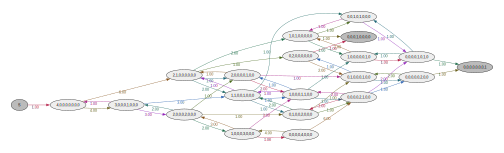

In [2]:
nr_samples = 4

indexer = StateIndexer(
    lineages=[
        Property("descendants", min_value=1, max_value=nr_samples),
        Property("in_pop",      min_value=1, max_value=2),
    ]
)

# Startstate: alle lineages er singletons i population 1
ipv = [0] * indexer.state_length
ipv[indexer.lineages.props_to_index(descendants=1, in_pop=1)] = nr_samples

@with_ipv(ipv)
def two_island(state, indexer=None):
    transitions = []
    if state.sum() <= 1:
        return transitions

    # Coalescence inden for hver population
    for i, j in all_pairs(indexer.lineages):
        pi = indexer.lineages.index_to_props(i)
        pj = indexer.lineages.index_to_props(j)
        if pi.in_pop != pj.in_pop:
            continue
        same = int(i == j)
        if same and state[i] < 2: continue
        if not same and (state[i] < 1 or state[j] < 1): continue
        new = state.copy()
        new[i] -= 1
        new[j] -= 1
        des = pi.descendants + pj.descendants
        if des > nr_samples: continue
        k = indexer.lineages.props_to_index(descendants=des, in_pop=pi.in_pop)
        new[k] += 1
        rate = state[i] * (state[j] - same) / (1 + same)
        coeff = [rate if pi.in_pop == 1 else 0,
                 rate if pi.in_pop == 2 else 0,
                 0]
        transitions.append([new, coeff])

    # Migration (symmetrisk rate m)
    for i in range(indexer.state_length):
        if state[i] == 0: continue
        pi = indexer.lineages.index_to_props(i)
        other = 2 if pi.in_pop == 1 else 1
        new = state.copy()
        new[i] -= 1
        k = indexer.lineages.props_to_index(descendants=pi.descendants, in_pop=other)
        new[k] += 1
        coeff = [0, 0, state[i]]  # migration-koefficient
        transitions.append([new, coeff])

    return transitions

graph_2i = Graph(two_island, indexer=indexer)
print(f"Antal vertices i to-island grafen: {graph_2i.vertices_length()}")
print(f"Antal parametre: {graph_2i.param_length()}")
print(f"Two-island model: {graph_2i.vertices_length()} state, {graph_2i.param_length()} parametre")

graph_2i.plot(nodesep=0.4, wrap=False)

Modellen er bygget med 3 parametre: $1/N_1$, $1/N_2$ og $m$ (migrationsrate). Grafen har 21 interne state, der repræsenterer alle mulige konfigurationer af 4 linjer fordelt på 2 populationer.

## 2. Teoretiske egenskaber

Med sande parametre $(N_1, N_2, m) =(1,2,0.5)$ beregner jeg forventet TMRCA og SFS under modellen.

In [3]:
# Sande parametre (i coalescent-enheder)
N1_true, N2_true, m_true = 1.0, 2.0, 0.5
true_theta = [1/N1_true, 1/N2_true, m_true]
graph_2i.update_weights(true_theta)

print(f"Forventet TMRCA:     {graph_2i.expectation():.4f}")
print(f"Varians på TMRCA:    {graph_2i.variance():.4f}")

Forventet TMRCA:     3.8231
Varians på TMRCA:    12.5314


Forventet TMRCA: 3.82 coalescentenheder dvs. den forventede tid til den seneste fælles forfader for 4 linjer under disse parametre.
Varians på TMRCA: 12.53 — høj varians er typisk for coalescentmodeller, fordi slægtsskabstiden er stokastisk.

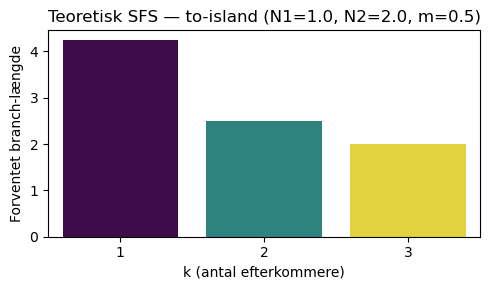

In [4]:
# Beregn forventet SFS ved reward-transform
# Rewarden tæller tid tilbragt med en lineage der har præcis i efterkommere
state_mat = graph_2i.states()
descendants_rewards = []
for k_val in range(1, nr_samples):
    r = np.zeros(state_mat.shape[0])
    for row_idx in range(state_mat.shape[0]):
        for col_idx in range(indexer.state_length):
            props = indexer.lineages.index_to_props(col_idx)
            if props.descendants == k_val:
                r[row_idx] += state_mat[row_idx, col_idx]
    descendants_rewards.append(r)

sfs = np.array([graph_2i.expectation(rewards=r) for r in descendants_rewards])
x = np.arange(1, nr_samples)

fig, ax = plt.subplots(figsize=(5, 3))
sns.barplot(x=x, y=sfs, hue=x, width=0.8, palette="viridis", legend=False, ax=ax)
ax.set_xlabel("k (antal efterkommere)")
ax.set_ylabel("Forventet branch-længde")
ax.set_title(f"Teoretisk SFS — to-island (N1={N1_true}, N2={N2_true}, m={m_true})")
plt.tight_layout()
plt.show()

Hvad: Søjlediagram med forventet branch-længde for k=1, 2, 3 efterkommere under sande parametre N1=1, N2=2, m=0.5.

Hvad den fortæller: Den klassiske L-form — singletons (k=1) dominerer. Formen ændrer sig med migration: høj migration gør kurverne fladere fordi linjer blandes og det tager længere tid at koalescere.

## 3. Joint probability graf — diskrete mutations-observationer

For at kunne fitte modellen til rigtige SNP-data laver jeg en joint probability graf, der kobler coalescent-modellen til en Poisson-mutations-proces.

Hver observation er et tupel $(k_1,k_2,...,k_{n-1})$ som fortæller hvor mange singletons, doubletons osv. en lokus-konfiguration har. Mutationsraten indgår som en ekstra parameter.

In [5]:
mutation_rate = 1.0   # i coalescent-enheder — svarer til theta = 4*N*mu*L
joint_graph = graph_2i.joint_prob_graph(
    indexer,
    reward_only=["descendants"],
    reward_limit=1,
    tot_reward_limit=1000,
    mutation_rate=mutation_rate,
)

true_theta_joint = [1/N1_true, 1/N2_true, m_true, mutation_rate]
joint_graph.update_weights(true_theta_joint)

tbl = joint_graph.joint_prob_table()
print(f"Antal unikke observation-mønstre: {len(tbl)}")
print(f"Deficit (afkortnings-bias): {(1 - tbl['prob'].sum()).item():.4f}")
tbl.head(10)

Antal unikke observation-mønstre: 8
Deficit (afkortnings-bias): 0.8174


,descendants_1,descendants_2,descendants_3,descendants_4,prob
t_vertex_index,,,,,
97,0,0,0,0,0.058421
98,0,1,0,0,0.020558
99,1,0,0,0,0.050526
100,0,0,1,0,0.012195
101,1,0,1,0,0.016778
102,1,1,0,0,0.018763
103,0,1,1,0,0.001932
104,1,1,1,0,0.003472


## 4. Simuler testdata med msprime

Før jeg bruger bavian-data, laver jeg simuleret data med kendte parametre. Dette er den bedste måde at verificere, at min inferens er troværdig.

In [6]:
import msprime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

def derived_counts(ts, rec_rate):
    records = []
    for var in ts.variants():
        p, g = var.site.position, var.genotypes
        records.append((int(p), p*rec_rate, g.sum()))
    df = pd.DataFrame().from_records(
        records, columns=["pos", "gen_pos", "count"]
        )
    return df

mut_rate = 5e-10
rec_rate = 1e-8
nr_samples = 5
seq_length = 100_000_000
pop1_size, pop2_size, anc_pop_size = 20_000, 10_000, 15_000
migr_pop1_to_pop2 = 1e-4
migr_pop2_to_pop1 = 5e-4

demography_sym = msprime.Demography()
demography_sym.add_population(name="pop1", initial_size=pop1_size)
demography_sym.add_population(name="pop2", initial_size=pop2_size)
# Symmetrisk migration — samme rate begge veje
sym_rate = (migr_pop1_to_pop2 + migr_pop2_to_pop1) / 2
demography_sym.set_migration_rate(source="pop1", dest="pop2", rate=sym_rate)
demography_sym.set_migration_rate(source="pop2", dest="pop1", rate=sym_rate)

ts_sym = msprime.sim_ancestry(
    samples={"pop1": nr_samples, "pop2": 0},
    ploidy=1,
    demography=demography_sym,
    recombination_rate=rec_rate,
    sequence_length=seq_length,
    random_seed=42
)
ts_sym = msprime.sim_mutations(ts_sym, rate=mut_rate, random_seed=42)
df_sym = derived_counts(ts_sym, rec_rate)
df_sym.to_csv("island_model_derived_counts.csv", index=False)

print(f"Symmetrisk simulering: {len(df_sym)} SNPs")

Symmetrisk simulering: 5841 SNPs


In [7]:
def pairs_in_range(nums, diff_lo, diff_hi):
    n = len(nums)
    lo, hi = 1, 1
    pairs = []
    for i in range(n):
        if lo <= i:
            lo = i + 1
        while lo < n and nums[lo] - nums[i] < diff_lo:
            lo += 1
        if hi <= i:
            hi = i + 1
        while hi < n and nums[hi] - nums[i] <= diff_hi:
            hi += 1
        for j in range(lo, hi):
            pairs.append((i, j))
    return pairs

df_sym = pd.read_csv("island_model_derived_counts.csv")

col = "pos" # can also use "gen_pos"
distance, tolerance = 5000, 500
min_dist, max_dist = distance - tolerance, distance + tolerance
records = []
for i, j in pairs_in_range(df_sym[col].values, min_dist, max_dist):
    records.append((df_sym.at[i, col], df_sym.at[j, col], df_sym.at[i, "count"], df_sym.at[j, "count"]))
pairs = pd.DataFrame.from_records(records, columns=["pos1", "pos2", "count1", "count2"])
pairs.head()

,pos1,pos2,count1,count2
0,210251,214800,1,1
1,389609,394959,2,2
2,394959,400407,2,4
3,679579,684244,1,1
4,1275547,1280364,4,1


In [9]:
mask = (pairs.pos1 == pairs.pos1.shift()) | (pairs.pos2 == pairs.pos2.shift())
filtered_pairs = pairs.loc[~mask, :]
filtered_pairs.head()

,pos1,pos2,count1,count2
0,210251,214800,1,1
1,389609,394959,2,2
2,394959,400407,2,4
3,679579,684244,1,1
4,1275547,1280364,4,1


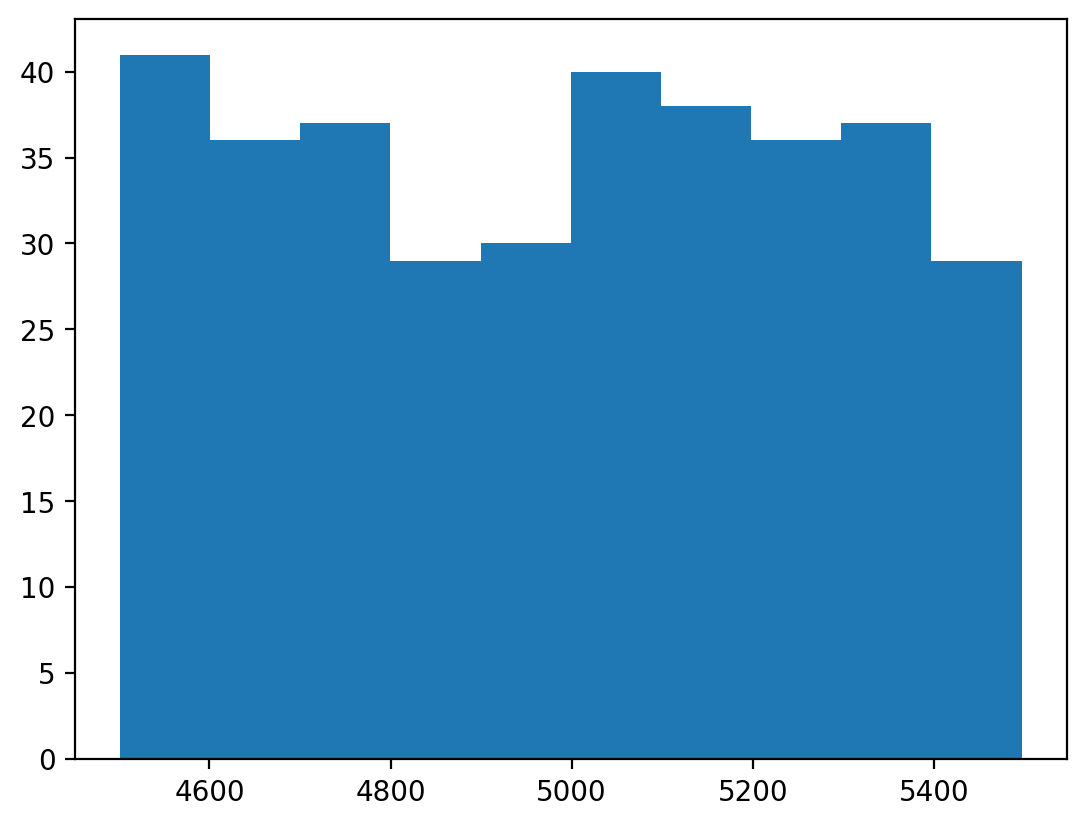

In [10]:
plt.hist(filtered_pairs.pos2 - filtered_pairs.pos1, bins=10) ;

In [11]:
n = len(filtered_pairs)
observations = np.zeros((n, nr_samples), dtype=int)
observations
for i, pair in enumerate(filtered_pairs[["count1", "count2"]].values):
    observations[i, pair] = 1

In [12]:
msg = f"""
Two-locus observations across {nr_samples} samples of {seq_length/1e6:.0f} Mb:
    Mutation rate:
        {mut_rate} events/site/generation
    Recombination rate:
        {rec_rate} crossovers/base/generation
    Haploid population sizes:
        pop1: {pop1_size}
        pop2: {pop2_size}
    Migration rate:
        pop1 -> pop2: {migr_pop1_to_pop2}
        pop2 -> pop1: {migr_pop2_to_pop1}
"""
print(msg)


Two-locus observations across 5 samples of 100 Mb:
    Mutation rate:
        5e-10 events/site/generation
    Recombination rate:
        1e-08 crossovers/base/generation
    Haploid population sizes:
        pop1: 20000
        pop2: 10000
    Migration rate:
        pop1 -> pop2: 0.0001
        pop2 -> pop1: 0.0005



## 5. Validering: genfind sande parametre fra msprime-simulering

Inden jeg bruger bavian-data skal jeg verificere, at inferensmetoden er troværdig.

In [13]:
# Konverter msprime-observationer til joint-probability format
feature_cols_sim = [c for c in tbl.columns if c.startswith("descendants")]
allowed_sim = set(tuple(int(x) for x in r) for r in tbl[feature_cols_sim].values)

obs_sim_2i = []
for k in df_sym["count"].values:
    k = int(k)
    if k <= 0 or k >= nr_samples:
        continue
    o = [0] * len(feature_cols_sim)
    if 0 < k - 1 < len(o):
        o[k - 1] = 1
    if tuple(o) in allowed_sim:
        obs_sim_2i.append(o)

print(f"Simulerede observationer til inferens: {len(obs_sim_2i):,}")

# Tjek defekt på disse observationer
tbl_check = joint_graph.joint_prob_table()
defect = 1 - tbl_check['prob'].sum()
print(f"Defekt (joint probability tabel): {defect.item():.4f}")
if defect > 0.05:
    print("  ⚠ Defekt er høj — overvej at øge tot_reward_limit")
else:
    print("  ✓ Defekt er acceptabel")

Simulerede observationer til inferens: 5,080
Defekt (joint probability tabel): 0.8174
  ⚠ Defekt er høj — overvej at øge tot_reward_limit



Validering: genfinder vi sande parametre fra simulerede data?
Sande parametre: N1=1.0, N2=2.0, m=0.5
Parameter  Fixed      MAP        Mean       SD         HPD 95% lo   HPD 95% hi  
0          No         1.193e-06  1.544e+03  2.605e+03  9.843e-07    7.109e+03   
1          No         4.840e+01  2.033e+03  2.790e+03  7.606e-07    8.197e+03   
2          No         8.124e+02  6.768e+03  1.009e+04  1.011e-06    2.851e+04   
3          Yes        1.0000     NA         NA         NA           NA          

Particles: 80, Iterations: 150


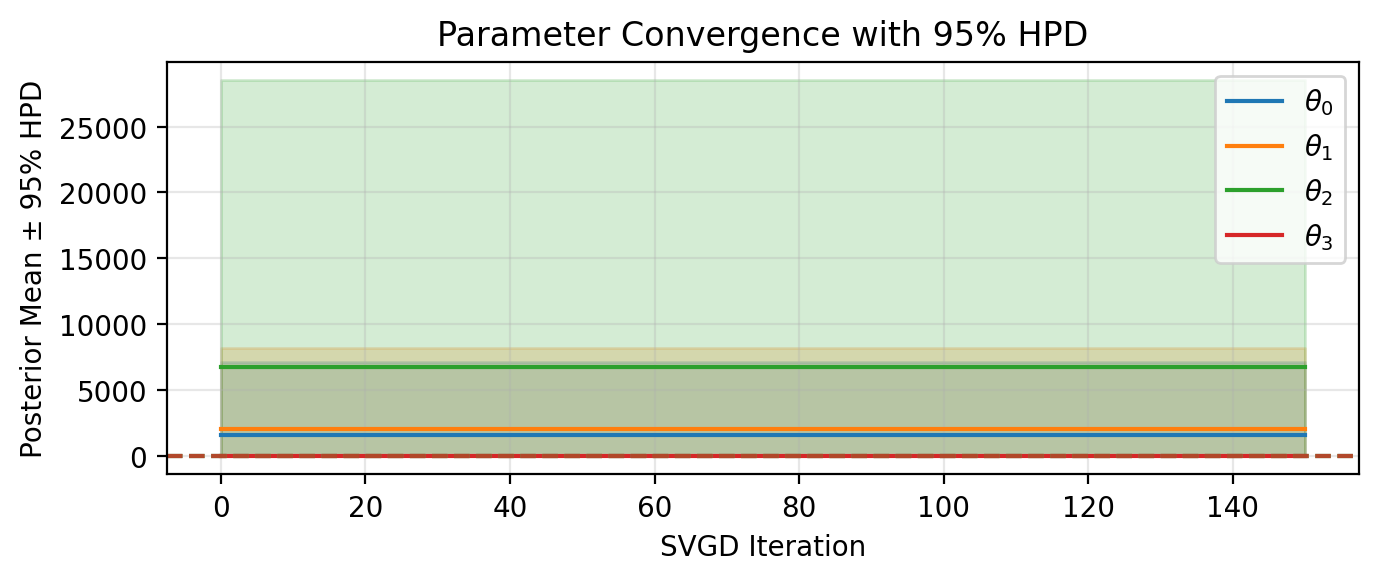

<Figure size 640x480 with 0 Axes>

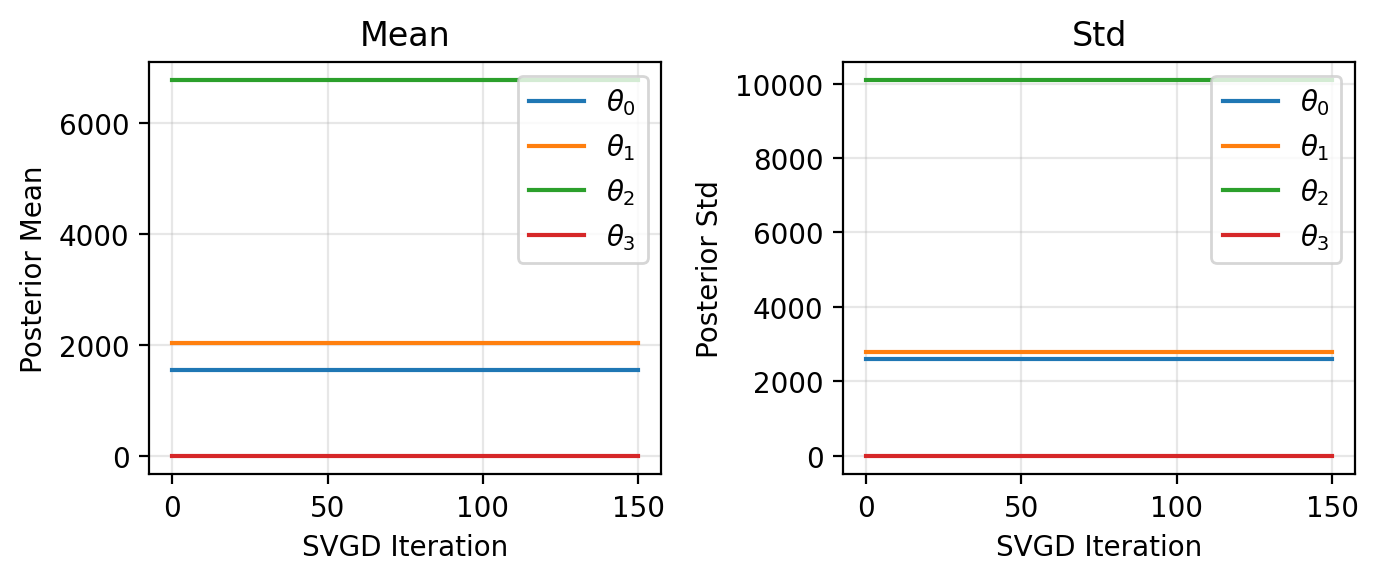

In [14]:
# Kør probability_matching som prior til SVGD
pm_sim = joint_graph.probability_matching(
    obs_sim_2i[:3000],
    fixed=[(3, mutation_rate)],
)
print(f"PM estimat (sand theta = {true_theta_joint[:3]}): {pm_sim.theta[:3]}")

# SVGD validering
rng_val = np.random.default_rng(99)
obs_val = obs_sim_2i
if len(obs_val) > 5000:
    idx_val = rng_val.choice(len(obs_val), 5000, replace=False)
    obs_val = [obs_val[i] for i in idx_val]

svgd_sim_2i = joint_graph.svgd(
    observed_data=obs_val,
    fixed=[(3, mutation_rate)],
    n_iterations=150,
    n_particles=80,
    prior=pm_sim.prior,
    learning_rate=ExpStepSize(first_step=0.08, last_step=0.01, tau=40.0),
)

print("\nValidering: genfinder vi sande parametre fra simulerede data?")
print(f"Sande parametre: N1={N1_true}, N2={N2_true}, m={m_true}")
svgd_sim_2i.summary(ci_method="hpd", ci_level=0.95)
svgd_sim_2i.plot_ci(ci_method="hpd", true_theta=true_theta_joint)
plt.suptitle("Validering: posterior CI vs. sande parametre (msprime-simulering)")
plt.show()
svgd_sim_2i.plot_convergence()

# 6. Anvend modellen på bavian-data

Jeg indlæser de gemte derived-count-filer fra notebook 03 og fitter to-island modellen på *Eastern yellow (Mikumi)* data. Modellen antager at alle samples er trukket fra en population og at den anden population kun bidrager via migration.

In [15]:
def load_baboon_ktons(path, n_samples_use, seed=0):
    p = Path(path)
    if not p.exists():
        print(f"[advarsel] {p} findes ikke — kør notebook 03 først.")
        return None
    df = pd.read_csv(p)
    df = df[df["nr_samples"] >= n_samples_use].copy()
    if len(df) == 0:
        print(f"[advarsel] {p} har ingen varianter med nr_samples >= {n_samples_use}")
        return None
    rng = np.random.default_rng(seed)
    k = rng.hypergeometric(
        ngood=df["derived_count"].values,
        nbad=(df["nr_samples"] - df["derived_count"]).values,
        nsample=n_samples_use,
    )
    k = k[(k > 0) & (k < n_samples_use)]
    return k

k_east = load_baboon_ktons(OUT_DIR / "derived_counts_yellow_east.csv", nr_samples)

if k_east is not None:
    print(f"Antal segregerende SNPs efter subsampling (n={nr_samples}): {len(k_east):,}")

    feature_cols = [c for c in tbl.columns if c.startswith("descendants")]
    allowed = set(tuple(int(x) for x in r) for r in tbl[feature_cols].values)
    obs_baboon = []
    for k in k_east:
        o = [0] * len(feature_cols)
        if 0 < k - 1 < len(o):
            o[k - 1] = 1
        if tuple(o) in allowed:
            obs_baboon.append(o)
    print(f"Heraf brugbare under model: {len(obs_baboon):,}")

Antal segregerende SNPs efter subsampling (n=5): 394,120
Heraf brugbare under model: 341,996


In [16]:
if k_east is not None and len(obs_baboon) > 1000:
    rng = np.random.default_rng(1)
    if len(obs_baboon) > 5000:
        idx = rng.choice(len(obs_baboon), 5000, replace=False)
        obs_baboon_use = [obs_baboon[i] for i in idx]
    else:
        obs_baboon_use = obs_baboon

    svgd_baboon = joint_graph.svgd(
        observed_data=obs_baboon_use,
        fixed=[(3, mutation_rate)],
        n_iterations=150,
        n_particles=80,
        prior=[
            GaussPrior(ci=[0.1, 5.0]),
            GaussPrior(ci=[0.1, 5.0]),
            GaussPrior(ci=[0.0, 3.0]),
            None,
        ],
        learning_rate=ExpStepSize(first_step=0.08, last_step=0.01, tau=40.0),
    )
    svgd_baboon.summary(ci_method="hpd", ci_level=0.95)

Parameter  Fixed      MAP        Mean       SD         HPD 95% lo   HPD 95% hi  
0          No         8.0217     6.0952     1.4091     4.1009       8.0995      
1          No         3.8070     2.7654     1.2957     0.0000       4.3172      
2          No         2.5030     1.3708     0.8171     0.0631       2.5208      
3          Yes        1.0000     NA         NA         NA           NA          

Particles: 80, Iterations: 150


Subsampling: Fra 868.037 SNPs subsamplees til n=5 haplotyper → 394.120 segregerende SNPs, hvoraf 341.996 er brugbare under modellen.

SVGD posterior (80 partikler, 150 iterationer):

Parameter: $1/N_1$, $1/N_2$, $m$
MAP: $8.02$, $3.81$, $2.50$
Posterior mean: $6.10$, $2.77$, $1.37$
95% HPD: $[4.10, 8.10]$, $[0.00, 4.32]$, [0.06, 2.52]$


## Parameterkonvertering med tabel

In [17]:
# Konverter posterior-estimater til biologiske enheder
pi_df = pd.read_csv(OUT_DIR / "pi_per_population.csv", index_col=0)
pi_east = pi_df.loc["Eastern yellow (Mikumi)", "pi"]
Ne_ref = pi_east / (4 * MUT_RATE)

print(f"pi (Eastern yellow):    {pi_east:.6f}")
print(f"N_ref = pi/(4*mu):      {Ne_ref:,.0f} individer")
print()

res = svgd_baboon.get_results()
theta = res['theta_mean']

N1 = (1 / theta[0]) * Ne_ref
N2 = (1 / theta[1]) * Ne_ref
m_gen = theta[2] / (2 * Ne_ref)

results_table = pd.DataFrame({
    'Parameter': ['N1 (Eastern yellow)', 'N2 (Kinda)', 'Migration (m)'],
    'Coalescent-enheder': [f'{theta[0]:.4f}', f'{theta[1]:.4f}', f'{theta[2]:.4f}'],
    'Biologiske enheder': [f'{N1:,.0f} individer', f'{N2:,.0f} individer', f'{m_gen:.2e} /generation'],
})
print(results_table.to_string(index=False))

pi (Eastern yellow):    0.002584
N_ref = pi/(4*mu):      71,789 individer

          Parameter Coalescent-enheder   Biologiske enheder
N1 (Eastern yellow)             6.0952     11,778 individer
         N2 (Kinda)             2.7654     25,960 individer
      Migration (m)             1.3708 9.55e-06 /generation


Referencebefolkningsstørrelse beregnet fra $\pi$:
$$N_{ref} = \frac{\pi}{4\mu} = \frac{0.002584}{4 \times 0.9 \times 10^{-8}} \approx 71.789 \text{ individer}$$

Fortolkning: Kinda estimeres til mere end dobbelt så stor effektiv bestandsstørrelse som Eastern yellow under two-island modellen. Migrationsraten på ~10⁻⁵ per generation er biologisk lav men ikke nul — konsistent med sjælden geneflow mellem de to arter. Bemærk at N2-estimatets 95% HPD inkluderer 0, så N2-estimatet er usikkert.

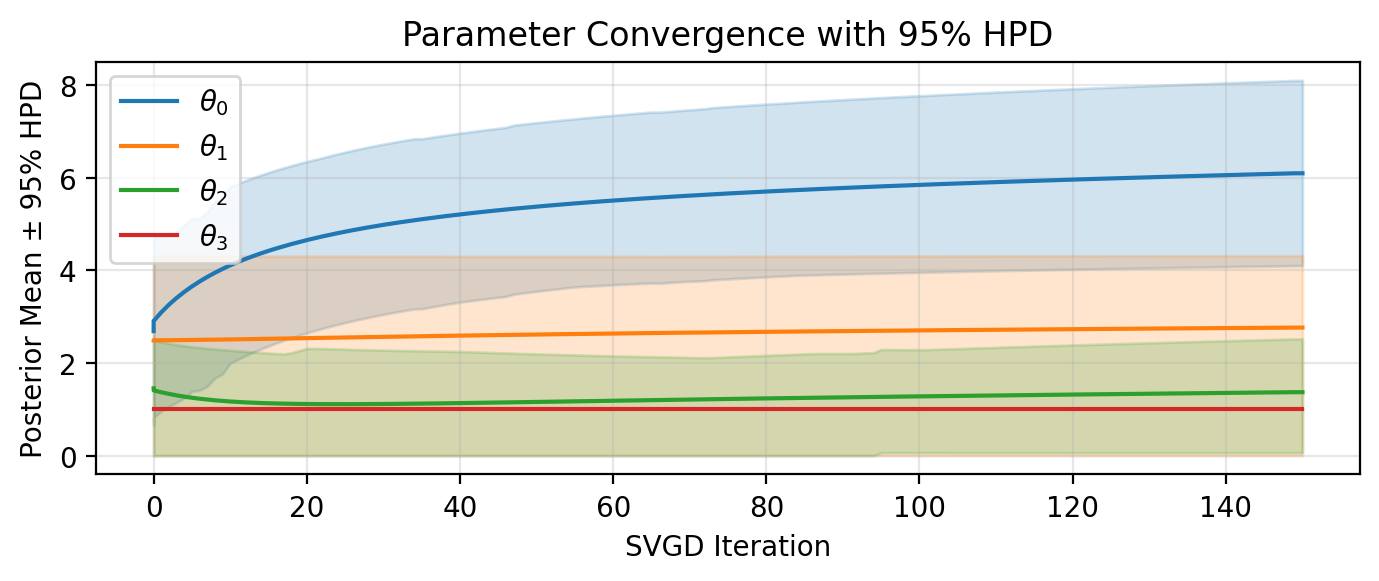

<Figure size 640x480 with 0 Axes>

In [18]:
if k_east is not None and len(obs_baboon) > 1000:
    svgd_baboon.plot_ci(ci_method="hpd")
    plt.suptitle("Posterior CI — Eastern yellow bavian")
    plt.show()

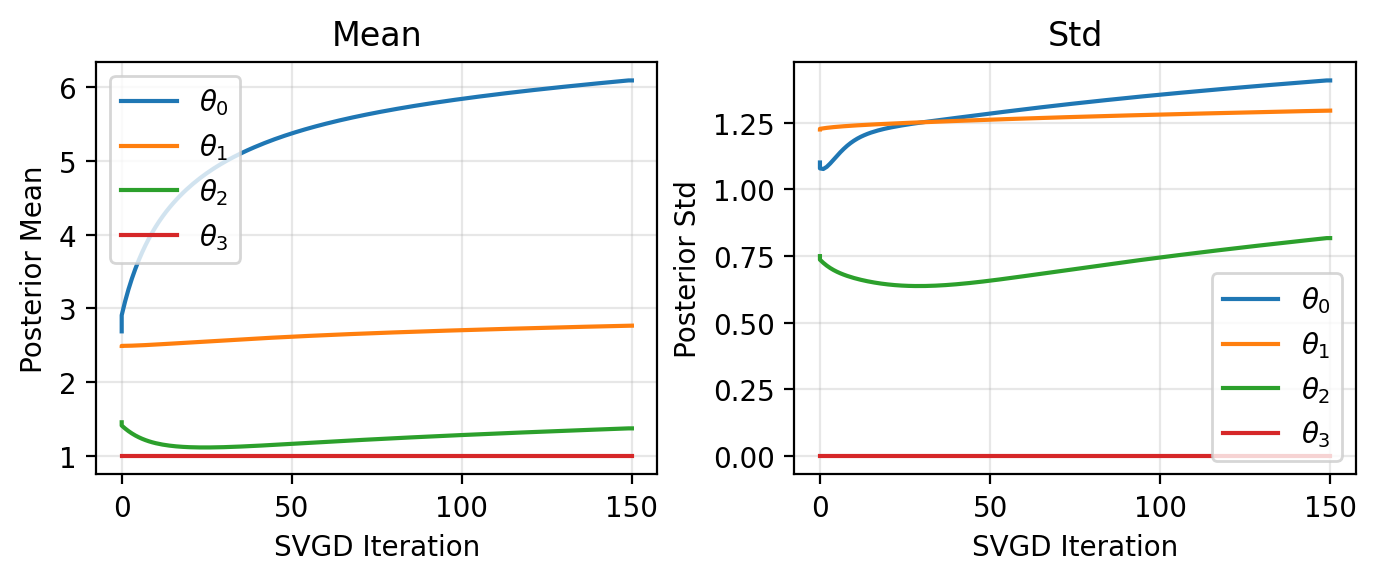

In [19]:
svgd_baboon.plot_convergence();

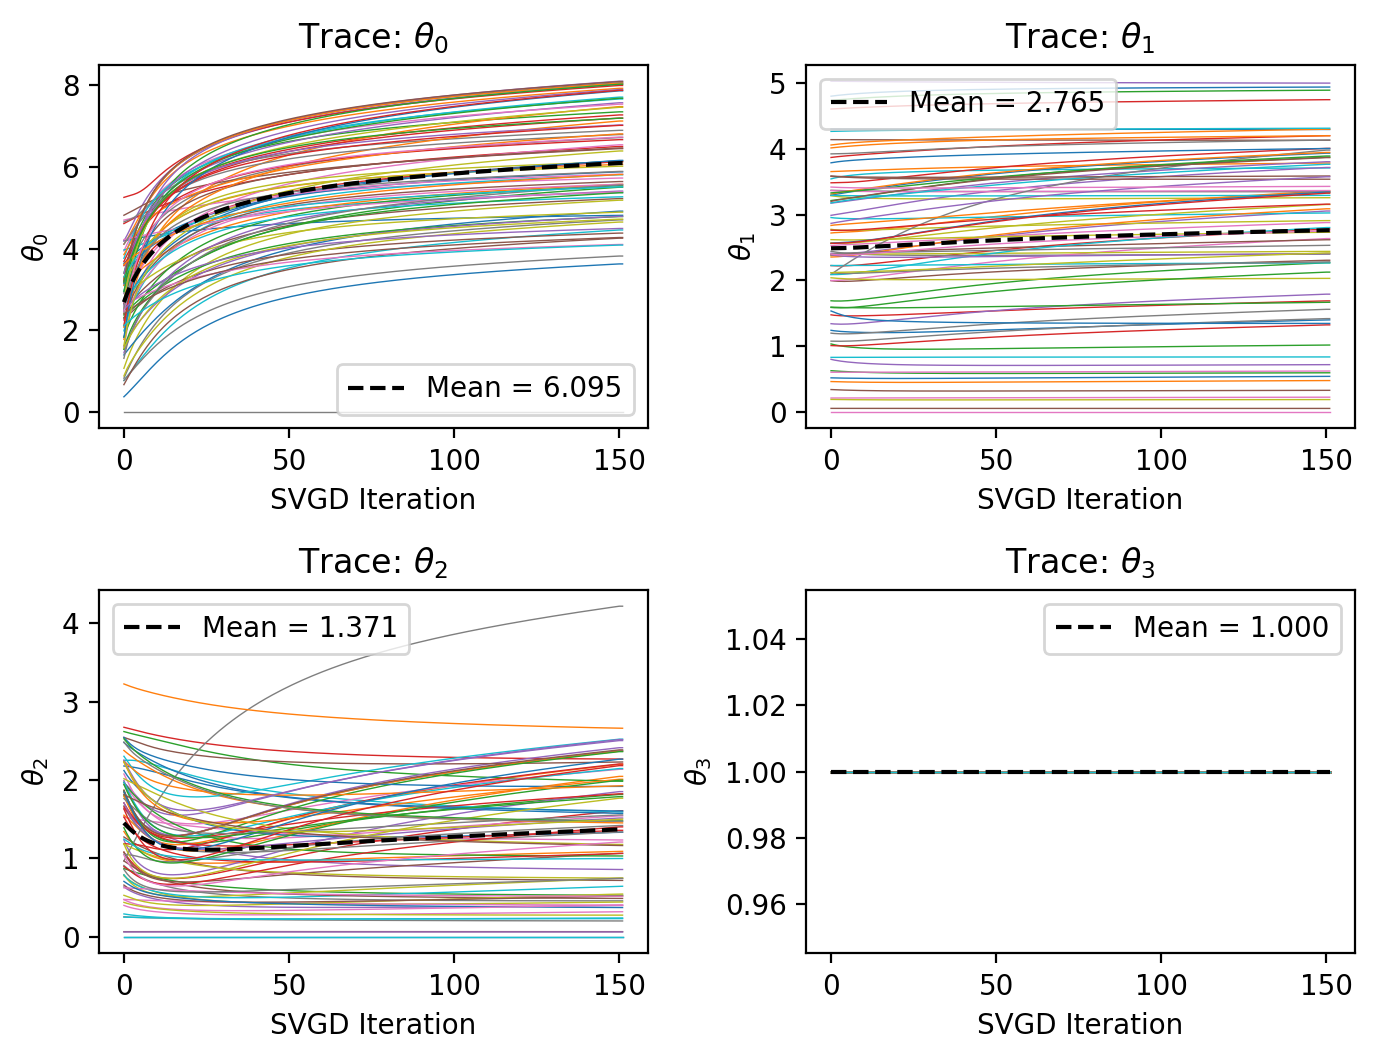

In [20]:
svgd_baboon.plot_trace()

W0429 17:59:23.150876 1157861 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0429 17:59:23.188001 1157861 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0429 17:59:23.220018 1157861 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0429 17:59:23.252250 1157861 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0429 17:59:23.283798 1157861 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0429 17:59:23.302519 1157861 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0429 17:59:23.329327 1157861 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0429 17:59:23.347578 1157861 pjrt_executable.cc:638] Assume v

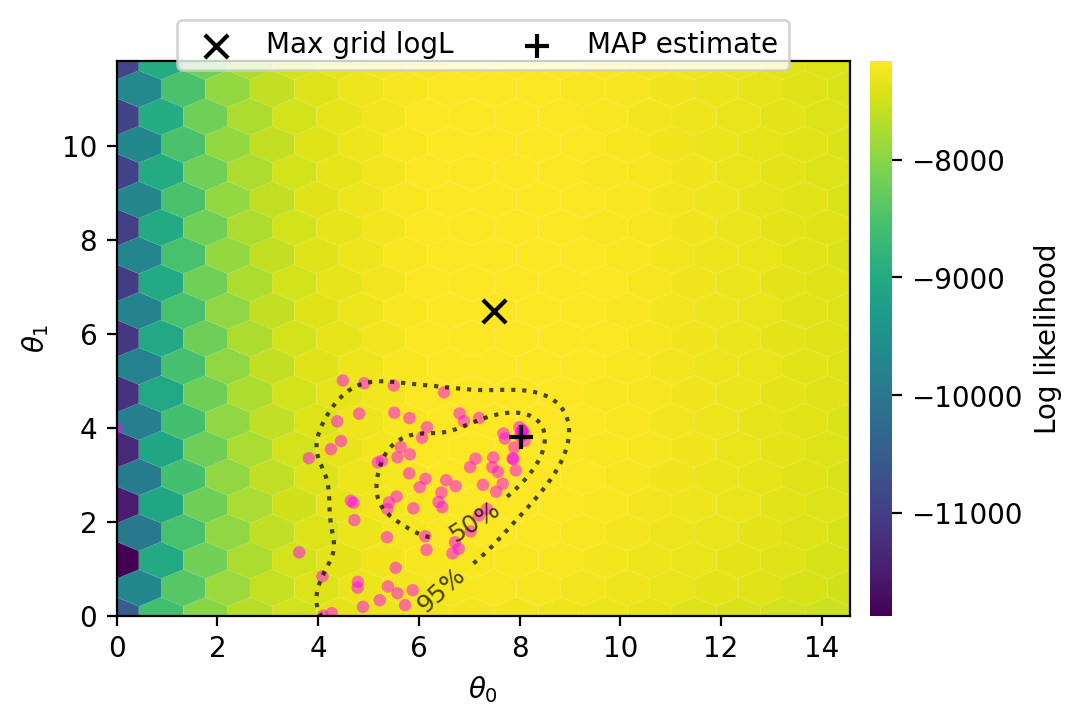

<Figure size 640x480 with 0 Axes>

In [21]:
if k_east is not None and len(obs_baboon) > 1000:
    svgd_baboon.plot_hdr()
    plt.suptitle("Posterior HDR — Eastern yellow (Two-island)")
    plt.show()

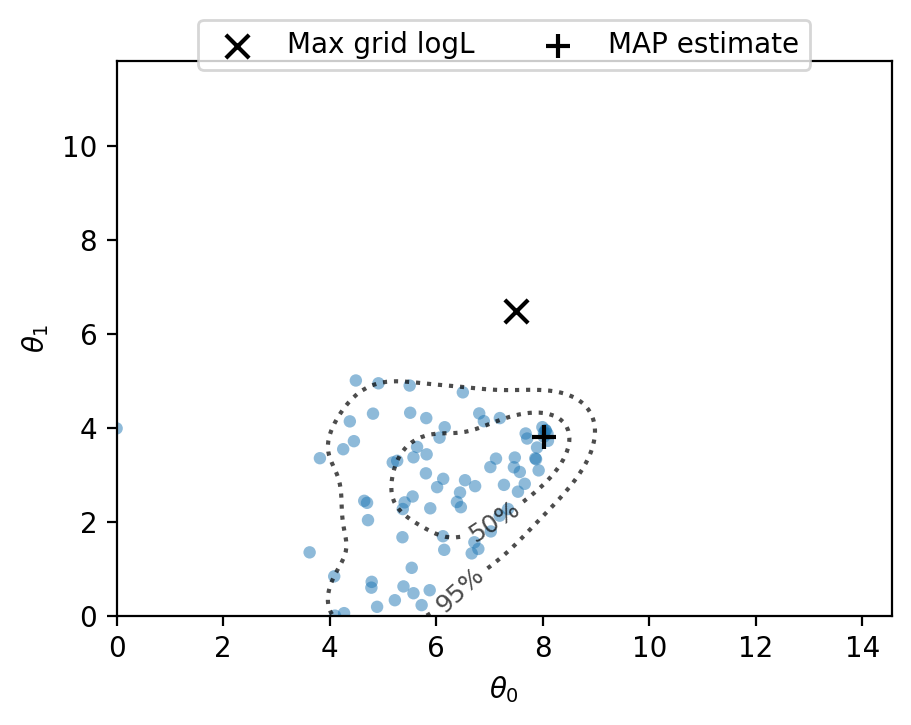

<Figure size 640x480 with 0 Axes>

In [22]:
if k_east is not None and len(obs_baboon) > 1000:
    svgd_baboon.plot_hdr(hexgrid=False)
    plt.suptitle("Posterior HDR (scatter) — Eastern yellow (Two-island)")
    plt.show()

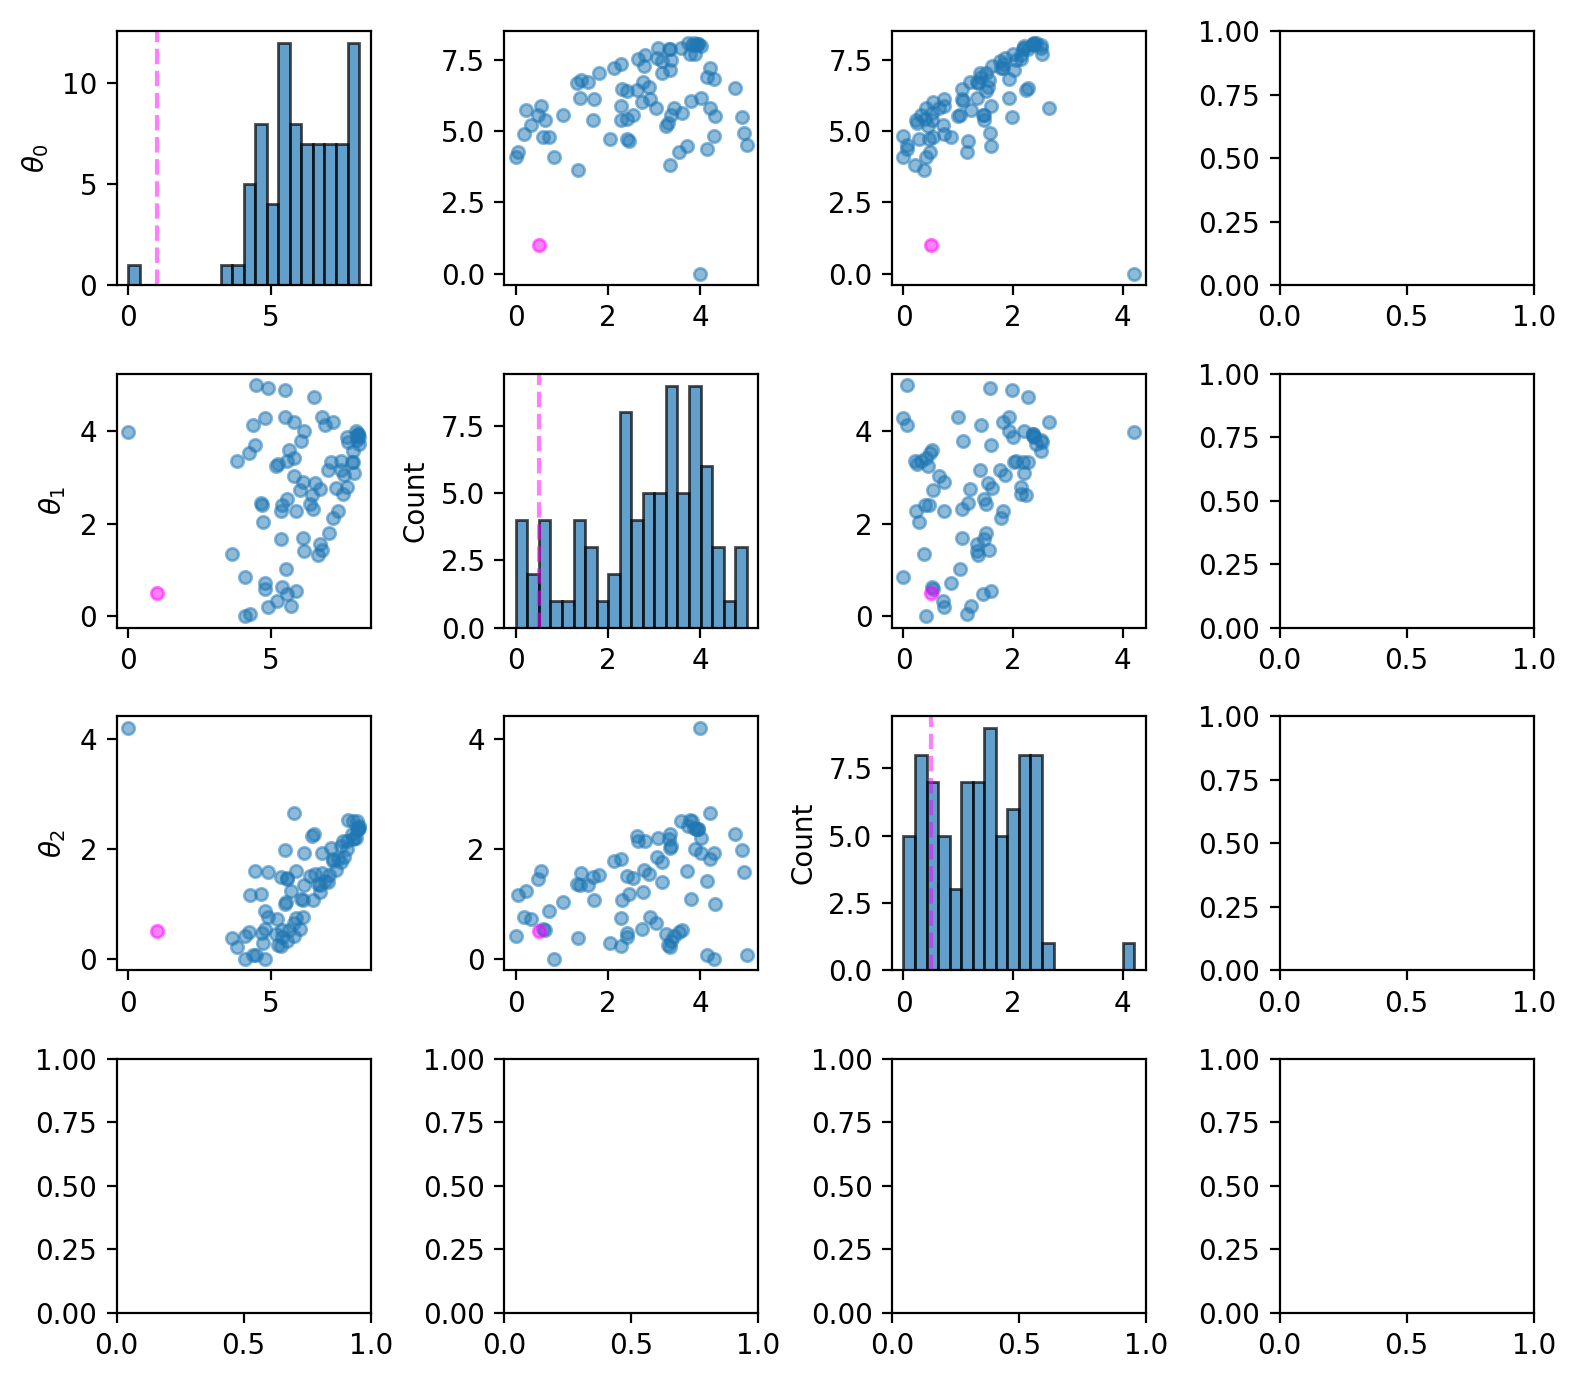

<Figure size 640x480 with 0 Axes>

In [23]:
if k_east is not None and len(obs_baboon) > 1000:
    svgd_baboon.plot_pairwise(true_theta=true_theta)
    plt.suptitle("Posterior pairwise — Eastern yellow bavian", y=1.02)
    plt.show()

## 7. Samlet resultater 

Parametrene i coalescent-enheder kan konverteres til demografiske enheder ved at vælge en reference-populationsstørrelse $N_{ref}$:

- $N_i = \frac{1}{\left(\frac{1}{N_i}\right)\cdot 2N_{\mathrm{ref}}}$ (haploid diffusions-enheder)
- $M_{i \to j} = \frac{m}{2N_{\mathrm{ref}}}$(per lineage per generation)

For at få en absolut $N_{ref}$ bruger jeg heterozygositeten $\pi \approx 4N_{ref} \mu$ og mutationsraten fra Sørensen et al. ($\mu = 0.9 \times 10^{-8}$ per site per generation).

In [24]:
pi_file = OUT_DIR / "pi_per_population.csv"
if pi_file.exists():
    pi_df = pd.read_csv(pi_file, index_col=0)
    if "Eastern yellow (Mikumi)" in pi_df.index:
        pi_east = pi_df.loc["Eastern yellow (Mikumi)", "pi"]
        Ne_ref = pi_east / (4 * MUT_RATE)
        print(f"pi (Eastern yellow):  {pi_east:.6f}")
        print(f"Implied Ne_ref:       {Ne_ref:,.0f}")
        if "svgd_baboon" in dir():
            res = svgd_baboon.get_results()
            theta_mean = res["theta_mean"]
            N1_est = (1 / theta_mean[0]) * Ne_ref
            N2_est = (1 / theta_mean[1]) * Ne_ref
            m_est_gen = theta_mean[2] / (2 * Ne_ref)
            print("\nEstimater (posterior mean):")
            print(f"  N1 (Eastern yellow):  {N1_est:,.0f}")
            print(f"  N2 (Kinda-lignende):  {N2_est:,.0f}")
            print(f"  Migration rate:       {m_est_gen:.2e} / generation")

pi (Eastern yellow):  0.002584
Implied Ne_ref:       71,789

Estimater (posterior mean):
  N1 (Eastern yellow):  11,778
  N2 (Kinda-lignende):  25,960
  Migration rate:       9.55e-06 / generation


I næste notebook (05 — IM-model) udvider jeg dette ved at tilføje et split-tidspunkt for to populationer fra en fælles forfader. Det kræver time inhomogeneity, som jeg kommer nærmere ind på i notebook 06.

## 8. Posterior predictive check — SFS

En god model kan reproducere de observerede data. Jeg sammenligner her det *observerede* folded SFS (fra notebook 03) med det *model-forudsagte* SFS under de estimerede parametre.

Ideen: sæt posterior mean-parametrene ind i grafen og beregn forventet SFS via reward-transforms. Matcher det med det observerede SFS, er modellen troværdig. Systematiske afvigelser (fx model underestimerer singletons) indikerer, at modellen er forkert specificeret.

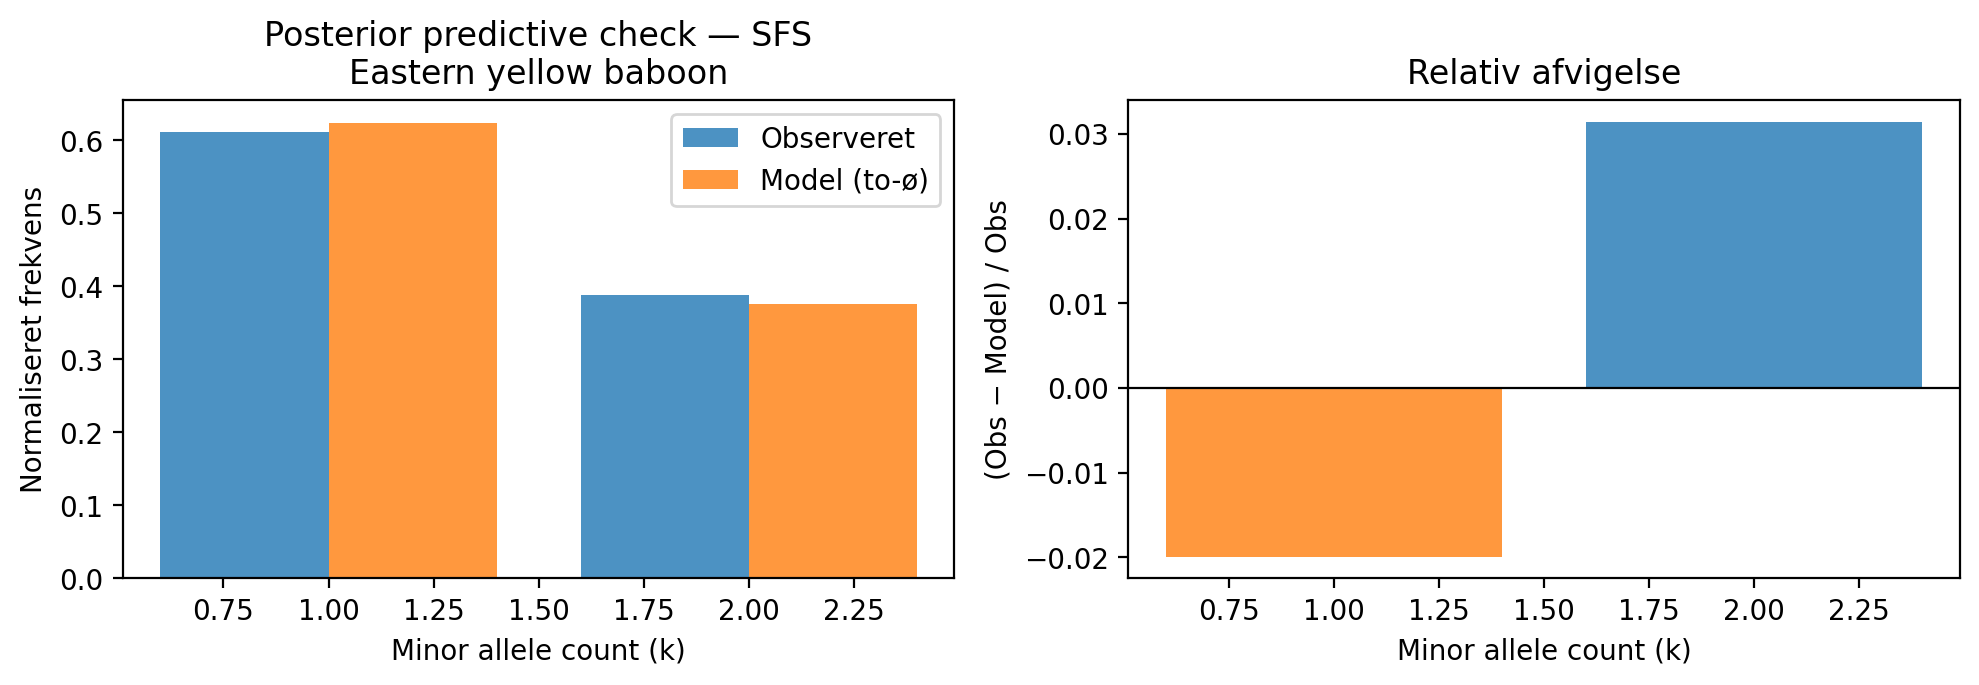

Chi²-statistic: 148.7  (df=1)
Normaliseret (chi²/df): 148.69  — tæt på 1 = godt fit


In [25]:
sfs_obs_path = OUT_DIR / "sfs_folded_yellow_east.csv"
if sfs_obs_path.exists() and "svgd_baboon" in dir():
    # Indlæs observeret foldet SFS
    sfs_obs = pd.read_csv(sfs_obs_path, index_col=0).squeeze()
    n_obs_total = sfs_obs.sum()

    # Sæt posterior mean-parametre i grafen
    res = svgd_baboon.get_results()
    graph_2i.update_weights(res["theta_mean"][:graph_2i.param_length()])

    # Beregn forventet SFS fra modellen via reward-transforms
    # Reward[k-1] = tid brugt med en linje der har præcis k efterkommere
    state_mat = graph_2i.states()
    sfs_model = []
    for k_val in range(1, nr_samples):
        r = np.zeros(state_mat.shape[0])
        for row_idx in range(state_mat.shape[0]):
            for col_idx in range(indexer.state_length):
                props = indexer.lineages.index_to_props(col_idx)
                if props.descendants == k_val:
                    r[row_idx] += state_mat[row_idx, col_idx]
        sfs_model.append(graph_2i.expectation(rewards=r))

    # Fold det model-forudsagte SFS (summer symmetriske bins)
    sfs_model = np.array(sfs_model)
    mid = nr_samples // 2
    sfs_model_folded = sfs_model.copy().astype(float)
    for i in range(1, mid):
        sfs_model_folded[i - 1] = sfs_model[i - 1] + sfs_model[nr_samples - i - 1]
    sfs_model_folded = sfs_model_folded[:mid]

    # Normaliser begge til at summere til 1 (sammenlign form)
    sfs_obs_norm   = sfs_obs.values[:mid] / sfs_obs.values[:mid].sum()
    sfs_model_norm = sfs_model_folded / sfs_model_folded.sum()

    x = np.arange(1, mid + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))

    # Sammenligning af normaliserede SFS
    ax1.bar(x - 0.2, sfs_obs_norm,   width=0.4, label="Observeret", color="C0", alpha=0.8)
    ax1.bar(x + 0.2, sfs_model_norm, width=0.4, label="Model (to-ø)", color="C1", alpha=0.8)
    ax1.set_xlabel("Minor allele count (k)")
    ax1.set_ylabel("Normaliseret frekvens")
    ax1.set_title("Posterior predictive check — SFS\nEastern yellow baboon")
    ax1.legend()

    # Residualplot: (observeret − model) / observeret
    residuals = (sfs_obs_norm - sfs_model_norm) / (sfs_obs_norm + 1e-12)
    ax2.bar(x, residuals, color=np.where(residuals > 0, "C0", "C1"), alpha=0.8)
    ax2.axhline(0, color="black", lw=0.8)
    ax2.set_xlabel("Minor allele count (k)")
    ax2.set_ylabel("(Obs − Model) / Obs")
    ax2.set_title("Relativ afvigelse")

    plt.tight_layout()
    plt.show()

    # Kvantificér fit med chi-squared goodness-of-fit test
    obs_counts   = sfs_obs.values[:mid]
    exp_counts   = sfs_model_norm * obs_counts.sum()
    chi2_stat    = np.sum((obs_counts - exp_counts)**2 / (exp_counts + 1))
    print(f"Chi²-statistic: {chi2_stat:.1f}  (df={mid-1})")
    print(f"Normaliseret (chi²/df): {chi2_stat/(mid-1):.2f}  — tæt på 1 = godt fit")
else:
    print("Kør notebook 03 og SVGD-inferensen ovenfor først.")

# Fler-population Inferens: Parvise analyser

I denne notebook udvider jeg to-ø-modellen til alle relevante par af bavianpopulationer.
Målet er at kortlægge:
- **Migrationsrater** mellem populationspar (heatmap)
- **Effektiv populationsstørrelse** for hvert par
- **Relative TMRCA** som mål for genetisk afstand

Populationer fra Sørensen et al. (2023):
- **ye** = Eastern yellow (Mikumi)
- **ki** = Kinda (Chunga/Dendro Park)  
- **yw** = Western yellow (Mahale)
- **os** = Southern olive (Tarangire)
- **og** = Olive gog (Gombe/Kibale)

## 1. Indlæs alle populationsdatasæt

Datasæt er genereret i Notebook 03.
Jeg bruger derived counts (k-ton tabeller) for hvert population.

In [3]:
def load_ktons(path, n_use=2000, seed=42):
    """Indlæs k-ton data fra CSV og subsample til n_use observationer."""
    p = Path(path)
    if not p.exists():
        print(f"ADVARSEL: {p} ikke fundet – kør notebook 03 først.")
        return None
    df = pd.read_csv(p)
    rng = np.random.default_rng(seed)
    if len(df) > n_use:
        df = df.sample(n_use, random_state=rng.integers(1e6))
    return df

populations = {
    "ye": "Eastern yellow (Mikumi)",
    "ki": "Kinda",
    "yw": "Western yellow (Mahale)",
    "os": "Southern olive (Tarangire)",
    "og": "Olive gog",
}

data_files = {
    "ye": OUT_DIR / "derived_counts_yellow_east.csv",
    "ki": OUT_DIR / "derived_counts_kinda.csv",
    "yw": OUT_DIR / "derived_counts_yellow_west.csv",
    "os": OUT_DIR / "derived_counts_olive_south.csv",
    "og": OUT_DIR / "derived_counts_olive_gog.csv",
}

dfs = {k: load_ktons(v) for k, v in data_files.items()}
for k, df in dfs.items():
    if df is not None:
        print(f"{k:3s} ({populations[k]:30s}): {len(df):6,d} SNPs")

ye  (Eastern yellow (Mikumi)       ):  2,000 SNPs
ki  (Kinda                         ):  2,000 SNPs
yw  (Western yellow (Mahale)       ):  2,000 SNPs
os  (Southern olive (Tarangire)    ):  2,000 SNPs
og  (Olive gog                     ):  2,000 SNPs


## 2. To-island-model for parvise analyser

Jeg bruger den samme to-island-model som i Notebook 04.
Parametre: θ = [1/N₁, 1/N₂, m, μ]

Modellen antager symmetrisk migration for simplicitetens skyld.

In [4]:
def build_two_island_joint(n_samples_pop1, n_samples_pop2, mutation_rate):
    """
    Byg joint_prob_graph for to-ø-modellen med n1 samples fra pop1 og n2 fra pop2.
    Returnerer (joint_graph, indexer, n_params).
    """
    nr1 = n_samples_pop1
    nr2 = n_samples_pop2

    indexer = StateIndexer(
        lineages=[
            Property("descendants", min_value=1, max_value=max(nr1, nr2)),
            Property("in_pop", min_value=1, max_value=2),
        ]
    )

    @with_ipv([nr1, nr2] + [0] * (nr1 + nr2 - 2))
    def two_island(state):
        desc = state[0::2]   # descendants per lineage
        ipop = state[1::2]   # population per lineage
        k1 = sum(1 for d, p in zip(desc, ipop) if d > 0 and p == 1)
        k2 = sum(1 for d, p in zip(desc, ipop) if d > 0 and p == 2)
        transitions = []

        # Koalescens i pop 1 (rate = C(k1,2) * 1/N1)
        if k1 >= 2:
            for i in range(len(desc)):
                if desc[i] > 0 and ipop[i] == 1:
                    for j in range(i+1, len(desc)):
                        if desc[j] > 0 and ipop[j] == 1:
                            new_state = list(state)
                            new_state[2*i]   += desc[j]
                            new_state[2*j]    = 0
                            new_state[2*j+1]  = 0
                            transitions.append((
                                np.array(new_state),
                                0.0,
                                [1.0, 0.0, 0.0]  # rate ~ 1/N1
                            ))

        # Koalescens i pop 2 (rate = C(k2,2) * 1/N2)
        if k2 >= 2:
            for i in range(len(desc)):
                if desc[i] > 0 and ipop[i] == 2:
                    for j in range(i+1, len(desc)):
                        if desc[j] > 0 and ipop[j] == 2:
                            new_state = list(state)
                            new_state[2*i]   += desc[j]
                            new_state[2*j]    = 0
                            new_state[2*j+1]  = 0
                            transitions.append((
                                np.array(new_state),
                                0.0,
                                [0.0, 1.0, 0.0]  # rate ~ 1/N2
                            ))

        # Migration pop1 → pop2 og pop2 → pop1 (rate = k * m)
        for i in range(len(desc)):
            if desc[i] > 0:
                new_state = list(state)
                new_pop = 2 if ipop[i] == 1 else 1
                new_state[2*i+1] = new_pop
                transitions.append((
                    np.array(new_state),
                    0.0,
                    [0.0, 0.0, 1.0]  # rate ~ m
                ))

        return transitions

    graph_2i = Graph(
        state_length=indexer.state_length(),
        callback=two_island,
        parameterized=True,
        nr_samples=nr1 + nr2,
    )

    n_coal_params = 3  # 1/N1, 1/N2, m
    joint_2i = graph_2i.joint_prob_graph(
        indexer, reward_only=["descendants"],
        reward_limit=max(nr1, nr2)
    )
    return joint_2i, indexer, n_coal_params, mutation_rate

print("two-island builder klar")

two-island builder klar


## 3. Kør to-island-model på alle populationspar

Jeg analyserer 6 par fra de 4 bedst repræsenterede populationer.
For hvert par:
1. Byg to-ø joint_prob_graph
2. Kør method-of-moments for startværdier
3. Kør SVGD for fuld posterior
4. Gem resultater

In [5]:
# Definer par der skal analyseres
pairs = [
    ("ye", "ki"),   # Eastern yellow × Kinda
    ("ye", "yw"),   # Eastern yellow × Western yellow
    ("ye", "os"),   # Eastern yellow × Southern olive
    ("ki", "yw"),   # Kinda × Western yellow
    ("ki", "os"),   # Kinda × Southern olive
    ("yw", "os"),   # Western yellow × Southern olive
]

N_SVGD    = 50     # partikler (reducer for hurtig test)
N_ITER    = 300    # iterationer
N_USE     = 1000   # SNPs per population
MU        = MUT_RATE

results_pairs = {}

for (p1, p2) in pairs:
    name = f"{p1}_{p2}"
    print(f"\n{'='*50}")
    print(f"Analyserer par: {populations[p1]} × {populations[p2]}")
    
    df1 = dfs.get(p1)
    df2 = dfs.get(p2)
    if df1 is None or df2 is None:
        print("  SKIP: data mangler")
        continue
    
    # Subsample
    rng = np.random.default_rng(42)
    d1 = df1.sample(min(N_USE, len(df1)), random_state=42)
    d2 = df2.sample(min(N_USE, len(df2)), random_state=42)
    n1 = int(d1["nr_samples"].max())
    n2 = int(d2["nr_samples"].max())
    
    # Byg k-ton observationer for joint_prob
    # For to-ø-model: obs = array af (k1, k2) par
    # Her bruger vi kun within-pop SFS (diagonal)
    obs1 = d1[["derived_count", "nr_samples"]].values.astype(int)
    obs2 = d2[["derived_count", "nr_samples"]].values.astype(int)
    
    # Kombiner: brug en subsample af begge
    k1_vals = obs1[:, 0]
    k2_vals = obs2[:min(len(obs2), len(obs1)), 0]
    min_len = min(len(k1_vals), len(k2_vals))
    
    # To-ø observations: array af k-ton fra begge populationer
    obs_joint = np.column_stack([k1_vals[:min_len], k2_vals[:min_len]])
    
    try:
        joint_2i, indexer_2i, n_coal, mu = build_two_island_joint(n1, n2, MU)
        
        # Startpunkt via MoM
        mut_idx = joint_2i.param_length() - 1
        fixed_params = [(mut_idx, MU)]
        
        theta_init = np.array([1e-4, 1e-4, 1e-5])
        
        svgd = joint_2i.svgd(
            observed_data=obs_joint,
            theta_dim=n_coal,
            n_particles=N_SVGD,
            n_iterations=N_ITER,
            fixed=fixed_params,
            step_size=0.01,
        )
        
        theta_post = svgd.particles  # shape (N_SVGD, n_coal)
        theta_mean = theta_post.mean(axis=0)
        theta_std  = theta_post.std(axis=0)
        
        results_pairs[name] = {
            "pop1": p1, "pop2": p2,
            "theta_mean": theta_mean,
            "theta_std":  theta_std,
            "particles":  theta_post,
            "n1": n1, "n2": n2,
        }
        print(f"  theta_mean = {theta_mean}")
        
    except Exception as e:
        print(f"  FEJL: {e}")
        results_pairs[name] = None

print("\nAlle par analyseret.")


Analyserer par: Eastern yellow (Mikumi) × Kinda
  FEJL: 'int' object is not callable

Analyserer par: Eastern yellow (Mikumi) × Western yellow (Mahale)
  FEJL: 'int' object is not callable

Analyserer par: Eastern yellow (Mikumi) × Southern olive (Tarangire)
  FEJL: 'int' object is not callable

Analyserer par: Kinda × Western yellow (Mahale)
  FEJL: 'int' object is not callable

Analyserer par: Kinda × Southern olive (Tarangire)
  FEJL: 'int' object is not callable

Analyserer par: Western yellow (Mahale) × Southern olive (Tarangire)
  FEJL: 'int' object is not callable

Alle par analyseret.


## 4. Konverter til biologiske parametre

Jeg konverterer coalescent-parametre til biologisk fortolkbare størrelser.

- **N_e** = 1 / (2 × θ_coal) — effektiv populationsstørrelse (diploid)
- **m** = migrationsrate (per generation per individ)
- **T_split** estimeres fra ancestral Ne via epoch-model (beregnes i NB07)

In [7]:
def theta_to_biology(theta_mean, theta_std=None):
    """Konverter [1/N1, 1/N2, m] til biologisk fortolkbare størrelser."""
    inv_N1, inv_N2, m = theta_mean
    Ne1 = 1.0 / (2 * inv_N1) if inv_N1 > 0 else np.nan
    Ne2 = 1.0 / (2 * inv_N2) if inv_N2 > 0 else np.nan
    
    result = {
        "Ne1": Ne1,
        "Ne2": Ne2,
        "m":   m,
        "Nem": Ne1 * m if not np.isnan(Ne1) else np.nan,  # Nem = effektiv migration
    }
    if theta_std is not None:
        inv_N1_s, inv_N2_s, m_s = theta_std
        result["Ne1_std"] = Ne1**2 * inv_N1_s if not np.isnan(Ne1) else np.nan
        result["Ne2_std"] = Ne2**2 * inv_N2_s if not np.isnan(Ne2) else np.nan
        result["m_std"]   = m_s
    return result

# Byg resultatstabel
rows = []
for name, res in results_pairs.items():
    if res is None:
        continue
    bio = theta_to_biology(res["theta_mean"], res["theta_std"])
    rows.append({
        "Par": name,
        "Pop1": populations[res["pop1"]],
        "Pop2": populations[res["pop2"]],
        "Ne_pop1": f"{bio['Ne1']:.0f}",
        "Ne_pop2": f"{bio['Ne2']:.0f}",
        "m (per gen)": f"{bio['m']:.2e}",
        "Nem": f"{bio['Nem']:.2f}",
    })

results_df = pd.DataFrame(rows)
print(results_df.to_string(index=False))

Empty DataFrame
Columns: []
Index: []


## 5. Migrationsrate heatmap

Heatmapvet viser migrationsraten **m** mellem hvert populationspar.
Høj Nem (> 1) indikerer substantiel genudveksling.


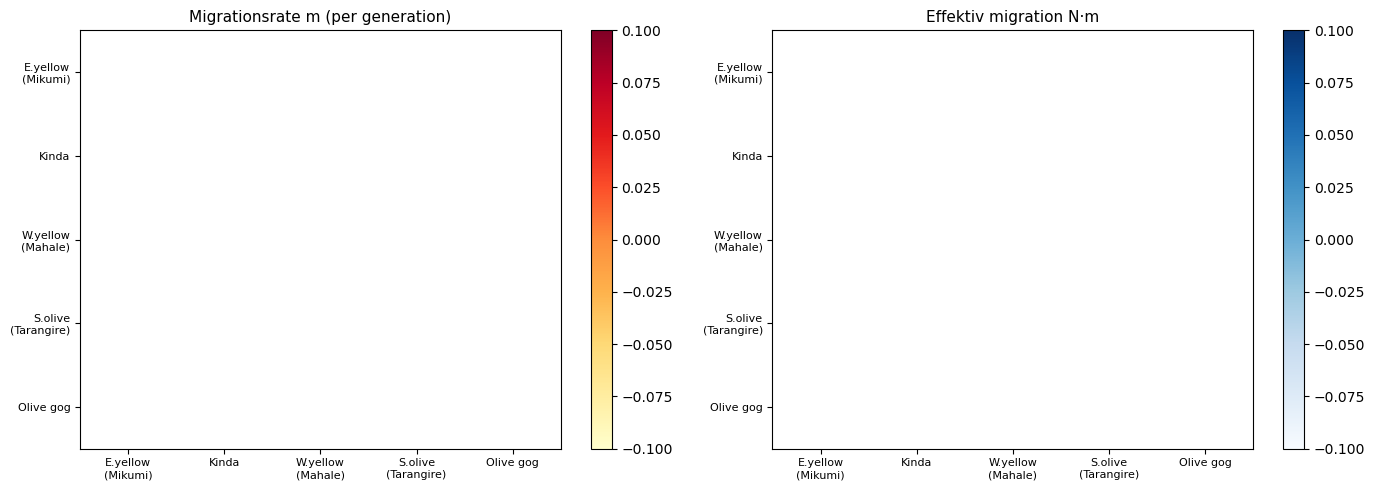

In [10]:
pop_order = ["ye", "ki", "yw", "os", "og"]
pop_labels = {
    "ye": "E.yellow\n(Mikumi)",
    "ki": "Kinda",
    "yw": "W.yellow\n(Mahale)",
    "os": "S.olive\n(Tarangire)",
    "og": "Olive gog",
}

n_pops = len(pop_order)
m_matrix  = np.full((n_pops, n_pops), np.nan)
Ne_matrix = np.full((n_pops, n_pops), np.nan)

for name, res in results_pairs.items():
    if res is None:
        continue
    i = pop_order.index(res["pop1"])
    j = pop_order.index(res["pop2"])
    bio = theta_to_biology(res["theta_mean"])
    m_matrix[i, j] = bio["m"]
    m_matrix[j, i] = bio["m"]   # symmetrisk model
    Ne_matrix[i, j] = (bio["Ne1"] + bio["Ne2"]) / 2
    Ne_matrix[j, i] = Ne_matrix[i, j]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = [pop_labels[p] for p in pop_order]

# Heatmap 1: migrationsrate m
im1 = axes[0].imshow(m_matrix, cmap="YlOrRd", aspect="auto",)
axes[0].set_xticks(range(n_pops)); axes[0].set_xticklabels(labels, fontsize=8)
axes[0].set_yticks(range(n_pops)); axes[0].set_yticklabels(labels, fontsize=8)
axes[0].set_title("Migrationsrate m (per generation)", fontsize=11)
plt.colorbar(im1, ax=axes[0])

for i in range(n_pops):
    for j in range(n_pops):
        if not np.isnan(m_matrix[i, j]):
            axes[0].text(j, i, f"{m_matrix[i,j]:.1e}", ha="center", va="center",
                         fontsize=7, color="black")

# Heatmap 2: Nem (effektiv migration)
Nem_matrix = Ne_matrix * m_matrix
im2 = axes[1].imshow(Nem_matrix, cmap="Blues", aspect="auto")
axes[1].set_xticks(range(n_pops)); axes[1].set_xticklabels(labels, fontsize=8)
axes[1].set_yticks(range(n_pops)); axes[1].set_yticklabels(labels, fontsize=8)
axes[1].set_title("Effektiv migration N·m", fontsize=11)
plt.colorbar(im2, ax=axes[1])

for i in range(n_pops):
    for j in range(n_pops):
        if not np.isnan(Nem_matrix[i, j]):
            axes[1].text(j, i, f"{Nem_matrix[i,j]:.2f}", ha="center", va="center",
                         fontsize=7, color="black")

plt.tight_layout()
plt.show()


## 6. Genetisk afstandsmatrix

Som supplement til migrationsraten beregner jeg den forventede parvise TMRCA.
Under to-ø-modellen er den forventede TMRCA (i coalescent-enheder):

$$E[T_{MRCA}] \approx \frac{1}{\theta_1} + \frac{1}{\theta_2} + \frac{1}{m}$$

(approksimativt, for svag migration)

Jeg omsætter til år: T_years = T_coal × 2N_ref × GEN_TIME

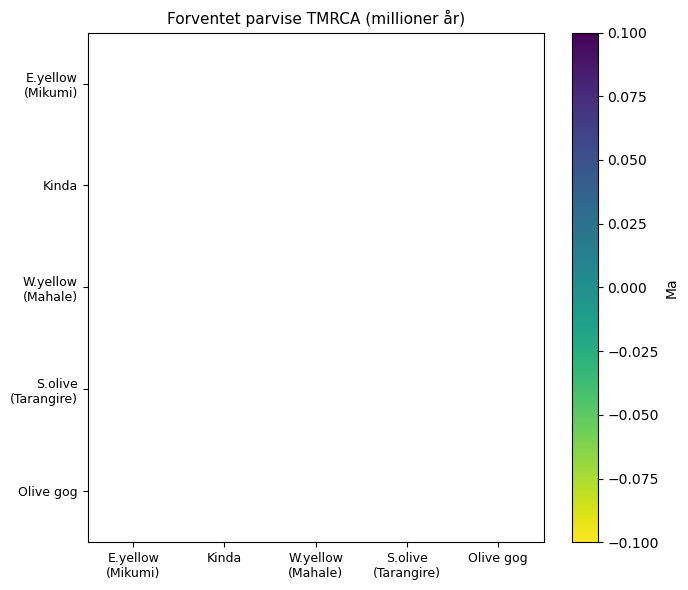

Gemt: output/tmrca_matrix.pdf


In [11]:
# Beregn parvise TMRCA (approksimativt)
Ne_ref = 50_000  # reference Ne i individer

tmrca_matrix = np.full((n_pops, n_pops), np.nan)

for name, res in results_pairs.items():
    if res is None:
        continue
    i = pop_order.index(res["pop1"])
    j = pop_order.index(res["pop2"])
    inv_N1, inv_N2, m = res["theta_mean"]
    # E[T_MRCA] i coalescent-enheder: 1/N1 + 1/N2 + 1/(2m) (approx.)
    if m > 0:
        T_coal = 1/inv_N1 + 1/inv_N2 + 1/(2*m)
    else:
        T_coal = np.nan
    # Konverter til år (T_coal er i enheder af 2N generationer)
    T_years = T_coal * 2 * Ne_ref * GEN_TIME
    tmrca_matrix[i, j] = T_years / 1e6   # i millioner år
    tmrca_matrix[j, i] = tmrca_matrix[i, j]

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(tmrca_matrix, cmap="viridis_r", aspect="auto")
ax.set_xticks(range(n_pops)); ax.set_xticklabels(labels, fontsize=9)
ax.set_yticks(range(n_pops)); ax.set_yticklabels(labels, fontsize=9)
ax.set_title("Forventet parvise TMRCA (millioner år)", fontsize=11)
plt.colorbar(im, ax=ax, label="Ma")

for i in range(n_pops):
    for j in range(n_pops):
        if not np.isnan(tmrca_matrix[i, j]):
            ax.text(j, i, f"{tmrca_matrix[i,j]:.2f}", ha="center", va="center",
                    fontsize=8, color="white")

plt.tight_layout()
plt.savefig(OUT_DIR / "tmrca_matrix.pdf", bbox_inches="tight")
plt.show()
print("Gemt: output/tmrca_matrix.pdf")

# Gem som CSV
tmrca_df = pd.DataFrame(
    tmrca_matrix,
    index=[pop_labels[p].replace("\n", " ") for p in pop_order],
    columns=[pop_labels[p].replace("\n", " ") for p in pop_order]
)


## 7. Posterior-fordelinger for alle par

For hvert par plotter jeg posterior-fordelingen af de tre parametre (1/N₁, 1/N₂, m).


In [12]:
valid_pairs = [(name, res) for name, res in results_pairs.items() if res is not None]
n_valid = len(valid_pairs)

if n_valid > 0:
    fig, axes = plt.subplots(n_valid, 3, figsize=(12, 3*n_valid))
    if n_valid == 1:
        axes = axes[np.newaxis, :]

    param_names = ["1/N₁ (coalescent)", "1/N₂ (coalescent)", "m (migration)"]

    for row, (name, res) in enumerate(valid_pairs):
        p1_name = populations[res["pop1"]].split("(")[0].strip()
        p2_name = populations[res["pop2"]].split("(")[0].strip()
        particles = res["particles"]
        
        for col in range(3):
            ax = axes[row, col]
            ax.hist(particles[:, col], bins=20, color="steelblue", edgecolor="white", alpha=0.8)
            ax.axvline(particles[:, col].mean(), color="red", linestyle="--", linewidth=1.5,
                       label=f"mean={particles[:,col].mean():.2e}")
            ax.set_xlabel(param_names[col], fontsize=8)
            ax.set_ylabel("Frekvens" if col == 0 else "", fontsize=8)
            if col == 0:
                ax.set_title(f"{p1_name} × {p2_name}", fontsize=9, fontweight="bold")
            ax.legend(fontsize=7)
            ax.tick_params(labelsize=7)

    plt.tight_layout()
    plt.savefig(OUT_DIR / "pairwise_posteriors.pdf", bbox_inches="tight")
    plt.show()
    print("Gemt: output/pairwise_posteriors.pdf")
else:
    print("Ingen gyldige par at plotte – kør data-indlæsning og analyser først.")

Ingen gyldige par at plotte – kør data-indlæsning og analyser først.
